In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

yu.setpath('plot_paper')

enss=['b','c','d','e']
stouts=[5,7,10,13,15,20]
stout_chosen=10

tfphys=[0.4,0.5,0.6,0.7,0.8,0.9,1.0]
tcphys=[0.05,0.1,0.15,0.2,0.25,0.3]
tftcphys=[(tfphy,tcphy) for tfphy in tfphys for tcphy in tcphys if tfphy>=2*tcphy]

ens2Njk={'b':725,'c':400,'d':493,'e':516}

js_conn=['j+;conn','j-;conn']
js_discq=['j+;disc','js;disc','jc;disc'] 
js_gluon=[f'jg;stout{nst}' for nst in stouts]
js_disc=js_discq+js_gluon

# tftcphy_A20_conn=tftcphy_A20_discq=tftcphy_A20_gluon=tftcphy_B20_conn=tftcphy_B20_discq=tftcphy_B20_gluon=(0.6,0.3)
# tftcphy_A20_conn=tftcphy_A20_discq=tftcphy_A20_gluon=tftcphy_B20_conn=tftcphy_B20_discq=tftcphy_B20_gluon=(0.6,0.1)

tftcphy_A20_conn=tftcphy_B20_conn=(0.8,0.3)
tftcphy_A20_discq=tftcphy_B20_discq=(0.6,0.2)
tftcphy_A20_gluon=tftcphy_B20_gluon=(0.6,0.3)

mpl.rcParams['lines.markersize'] = mpl.rcParams['errorbar.capsize'] = 8
mpl.rcParams['axes.labelsize'] = mpl.rcParams['axes.titlesize'] = mpl.rcParams['xtick.labelsize'] = mpl.rcParams['ytick.labelsize'] = 32
mpl.rcParams['font.size'] = 16
yu.mpl_global_elinewidth=yu.mpl_global_capthick=3

In [2]:
cttejn_key2bare_A20=yu.load_pkl_reg('step1/cttejn_key2bare_A20',pathlabel='analysis_xJ_syst')
ttej_key2bare_A20at0=yu.load_pkl_reg('step1/ttej_key2bare_A20at0',pathlabel='analysis_xJ_syst')

cttejn_key2bare_B20=yu.load_pkl_reg('step1/cttejn_key2bare_B20',pathlabel='analysis_xJ_syst')
ttej_key2bare_B20at0=yu.load_pkl_reg('step1/ttej_key2bare_B20at0',pathlabel='analysis_xJ_syst')

path='data_aux/RCs_np.pkl'
with open(path,'rb') as f:
    ens2RCs_np_me=pickle.load(f)
ens2RCs_np=yu.load_pkl_reg('ens2RCs_np_jk',pathlabel='processRenorms')


key2bare={}
for ens in enss:
    for j in js_conn:
        key2bare[(ens,j)]=ttej_key2bare_A20at0[(*tftcphy_A20_conn,ens,j)]
    for j in js_discq:
        key2bare[(ens,j)]=ttej_key2bare_A20at0[(*tftcphy_A20_discq,ens,j)]
    for j in js_gluon:
        nst=int(j.split('stout')[-1])
        key2bare[(ens,j)]=ttej_key2bare_A20at0[(*tftcphy_A20_gluon,ens,j)]
ej_key2bare_A20at0=key2bare

key2bare={}
for ens in enss:
    for j in js_conn:
        key2bare[(ens,j)]=ttej_key2bare_B20at0[(*tftcphy_B20_conn,ens,j)]
    for j in js_discq:
        key2bare[(ens,j)]=ttej_key2bare_B20at0[(*tftcphy_B20_discq,ens,j)]
    for j in js_gluon:
        nst=int(j.split('stout')[-1])
        key2bare[(ens,j)]=ttej_key2bare_B20at0[(*tftcphy_B20_gluon,ens,j)]
ej_key2bare_B20at0=key2bare

In [3]:
for q2 in [0,1,2,3,4]:
    print(q2,yu.formatList([yum.n2qpp12Q2((q2,q2,0),ens) for ens in enss],'>6.2g'))

0 [     0,     0,     0,     0]
1 [ 0.058, 0.051, 0.051,  0.05]
2 [  0.12,   0.1,   0.1,   0.1]
3 [  0.17,  0.15,  0.15,  0.15]
4 [  0.22,   0.2,   0.2,  0.19]


In [ ]:
# js=['j-;conn','j+;conn','j+;disc','js;disc','jc;disc','jg;stout10']
# index=[r'${A}_{20}^{u-d}(0)$',r'${A}_{20}^{u+d}(0)$ (conn)',r'${A}_{20}^{u+d}(0)$ (disc)',\
#     r'${A}_{20}^{s}(0)$',r'${A}_{20}^{c}(0)$',r'${A}_{20}^{g}(0)$']
# df=[[yu.jackme_un2str(ej_key2bare_A20at0[(ens,j)]) for ens in enss] for j in js]

# df=pd.DataFrame(df,index=index,columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

\begin{tabular}{ccccc}
 & B64 & C80 & D96 & E112 \\
\hline
${A}_{20}^{u-d}(0)$ & 0.141(13) & 0.1470(99) & 0.1376(95) & 0.1346(81) \\
${A}_{20}^{u+d}(0)$ (conn) & 0.416(36) & 0.432(25) & 0.394(20) & 0.327(23) \\
${A}_{20}^{u+d}(0)$ (disc) & 0.084(12) & 0.053(18) & 0.108(28) & 0.141(46) \\
${A}_{20}^{s}(0)$ & 0.0311(60) & 0.0191(86) & 0.043(14) & 0.069(20) \\
${A}_{20}^{c}(0)$ & 0.0063(48) & -0.0048(70) & 0.022(13) & 0.048(18) \\
${A}_{20}^{g}(0)$ & 0.387(28) & 0.514(39) & 0.383(67) & 0.588(95) \\
\end{tabular}



In [ ]:
# js=['j-;conn','j+;conn','j+;disc','js;disc','jc;disc','jg;stout10']
# index=[r'${B}_{20}^{u-d}(0)$',r'${B}_{20}^{u+d}(0)$ (conn)',r'${B}_{20}^{u+d}(0)$ (disc)',\
#     r'${B}_{20}^{s}(0)$',r'${B}_{20}^{c}(0)$',r'${B}_{20}^{g}(0)$']
# df=[[yu.jackme_un2str(ej_key2bare_B20at0[(ens,j)]) for ens in enss] for j in js]

# df=pd.DataFrame(df,index=index,columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

\begin{tabular}{ccccc}
 & B64 & C80 & D96 & E112 \\
\hline
${B}_{20}^{u-d}(0)$ & 0.179(36) & 0.144(26) & 0.181(20) & 0.212(20) \\
${B}_{20}^{u+d}(0)$ (conn) & -0.050(23) & -0.009(11) & -0.003(11) & -0.007(12) \\
${B}_{20}^{u+d}(0)$ (disc) & 0.002(16) & -0.013(18) & -0.029(31) & -0.002(39) \\
${B}_{20}^{s}(0)$ & 0.0025(80) & -0.0061(87) & -0.012(15) & 0.015(18) \\
${B}_{20}^{c}(0)$ & -0.0001(63) & 0.0008(73) & -0.008(13) & 0.011(16) \\
${B}_{20}^{g}(0)$ & -0.031(37) & -0.019(45) & -0.023(78) & 0.150(91) \\
\end{tabular}



In [3]:
colors=['r','g','b','orange']
js=['j-;conn','j+;conn']
ylabels=[r'${A}_{20}^{u-d}(Q^2)$',r'${A}_{20}^{u+d}(Q^2)$']

fig,axs=yu.getFigAxs(len(js),len(enss),Lrow=4,Lcol=8,sharex=True,sharey='row',gridspec_kw={'hspace':0.05, 'wspace':0.05})
xunit=1

for iens,ens in enumerate(enss):
    ax=axs[-1,iens]
    ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
    ax.set_xlim([-0.05,1.05])
    ax.set_xticks(np.arange(0,1.2,0.25))
    ax.set_xticklabels(['0','0.25','0.5','0.75','1'])
df=[]
for ij,j in enumerate(js):
    c1={'j+;conn':'unequal','j-;conn':'all'}[j]
    ax=axs[ij,0]
    ax.set_ylabel(ylabels[ij])
    df_row=[]
    for iens,ens in enumerate(enss):
        yunit=ens2RCs_np_me[ens]['Zqq(mu=nu)']/ens2RCs_np_me[ens]['Zqq(mu!=nu)'] if j in ['j-;conn'] else 1
        ax=axs[ij,iens]
        yu.addRefLine(ax,0,hv='v')
        color=yu.colors8[iens]
        yu.addRefLine(ax,0)
        
        tftcphy = tftcphy_A20_conn if j in js_conn else tftcphy_A20_discq if j in js_discq else tftcphy_A20_gluon if j in js_gluon else 1/0
        key2bare={cttejn[3:]:cttejn_key2bare_A20[cttejn] for cttejn in cttejn_key2bare_A20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        
        n2qpp1s=[key[-1] for key in key2bare.keys() if key[0]==ens and key[1]==j]
        Q2s=np.array([yum.n2qpp12Q2(n2qpp1,ens) for n2qpp1 in n2qpp1s])
        ys=np.array([key2bare[(ens,j,n2qpp1)][:] for n2qpp1 in n2qpp1s]).T
        
        mean,err=yu.jackme(ys)
        plt_x=Q2s*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
        
        if j in js_conn:
            Q2cut=1
            doFit=yu.doFit_dipole
            fitfunc=yu.fitfunc_dipole
        else:
            Q2cut=0.5
            doFit=yu.doFit_linear
            fitfunc=yu.fitfunc_linear
        inds=[i for i,Q2 in enumerate(Q2s) if Q2<=Q2cut]
        Q2s=Q2s[inds]
        ys=ys[:,inds]
    
        pars_jk,chi2_jk,Ndof=doFit(Q2s,ys,corrQ=False)
        
        xs_plt=np.arange(0,Q2cut+1e-5,0.05)
        y_plt=np.array([fitfunc(xs_plt,*pars) for pars in pars_jk])
        mean,err=yu.jackme(y_plt)
        plt_x=xs_plt*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.fill_between(plt_x,plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y[0],plt_yerr[0]))
        # ax.legend()
        df_row.append(yu.un2str(plt_y[0],plt_yerr[0]))
    df.append(df_row)

    ax.yaxis.set_major_locator(yu.MaxNLocator(nbins=4))
yu.finalizePlot('A20_Q2_conn',tightQ=False)

# df_A20_conn=df
# df=pd.DataFrame(df,index=[ylabel.replace('Q^2','0') for ylabel in ylabels],columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

In [23]:
colors=['r','g','b','orange']
js=['j-;conn','j+;conn']
ylabels=[r'${A}_{20}^{u-d}(Q^2)$',r'${A}_{20}^{u+d}(Q^2)$']

fig,axs=yu.getFigAxs(len(js),len(enss),Lrow=4,Lcol=8,sharex=True,sharey='row',gridspec_kw={'hspace':0.05, 'wspace':0.05})
xunit=1

for iens,ens in enumerate(enss):
    ax=axs[-1,iens]
    ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
    ax.set_xlim([-0.05,1.05])
    ax.set_xticks(np.arange(0,1.2,0.25))
    ax.set_xticklabels(['0','0.25','0.5','0.75','1'])
df=[]
for ij,j in enumerate(js):
    c1={'j+;conn':'unequal','j-;conn':'equal'}[j]
    ax=axs[ij,0]
    ax.set_ylabel(ylabels[ij])
    df_row=[]
    for iens,ens in enumerate(enss):
        yunit=1
        ax=axs[ij,iens]
        yu.addRefLine(ax,0,hv='v')
        color=yu.colors8[iens]
        yu.addRefLine(ax,0)
        
        tftcphy = tftcphy_A20_conn if j in js_conn else tftcphy_A20_discq if j in js_discq else tftcphy_A20_gluon if j in js_gluon else 1/0
        key2bare={cttejn[3:]:cttejn_key2bare_A20[cttejn] for cttejn in cttejn_key2bare_A20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        
        n2qpp1s=[key[-1] for key in key2bare.keys() if key[0]==ens and key[1]==j]
        Q2s=np.array([yum.n2qpp12Q2(n2qpp1,ens) for n2qpp1 in n2qpp1s])
        ys=np.array([key2bare[(ens,j,n2qpp1)][:] for n2qpp1 in n2qpp1s]).T
        
        mean,err=yu.jackme(ys)
        plt_x=Q2s*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
        
        if j in js_conn:
            Q2cut=1
            doFit=yu.doFit_dipole
            fitfunc=yu.fitfunc_dipole
        else:
            Q2cut=0.5
            doFit=yu.doFit_linear
            fitfunc=yu.fitfunc_linear
        inds=[i for i,Q2 in enumerate(Q2s) if Q2<=Q2cut]
        Q2s=Q2s[inds]
        ys=ys[:,inds]
    
        pars_jk,chi2_jk,Ndof=doFit(Q2s,ys,corrQ=False)
        if j=='j-;conn':
            yu.save_pkl_reg(f'A20_Q2_conn_equal_unequal_j-;conn_{ens}',pars_jk)
        
        xs_plt=np.arange(0,Q2cut+1e-5,0.05)
        y_plt=np.array([fitfunc(xs_plt,*pars) for pars in pars_jk])
        mean,err=yu.jackme(y_plt)
        plt_x=xs_plt*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.fill_between(plt_x,plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y[0],plt_yerr[0]))
        # ax.legend()
        df_row.append(yu.un2str(plt_y[0],plt_yerr[0]))
    df.append(df_row)

    ax.yaxis.set_major_locator(yu.MaxNLocator(nbins=4))
yu.finalizePlot('A20_Q2_conn_equal_unequal',tightQ=False)

# df_A20_conn=df
# df=pd.DataFrame(df,index=[ylabel.replace('Q^2','0') for ylabel in ylabels],columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

In [25]:
colors=['r','g','b','orange']
js=['j-;conn','j+;conn']
ylabels=[r'${B}_{20}^{u-d}(Q^2)$',r'${B}_{20}^{u+d}(Q^2)$']

fig,axs=yu.getFigAxs(len(js),len(enss),Lrow=4,Lcol=8,sharex=True,sharey='row',gridspec_kw={'hspace':0.05, 'wspace':0.05})
xunit=1

for iens,ens in enumerate(enss):
    ax=axs[-1,iens]
    ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
    ax.set_xlim([-0.05,1.05])
    ax.set_xticks(np.arange(0,1.2,0.25))
    ax.set_xticklabels(['0','0.25','0.5','0.75','1'])
df=[]
for ij,j in enumerate(js):
    c1='all' if j in ['j-;conn'] else 'unequal'
    ax=axs[ij,0]
    ax.set_ylabel(ylabels[ij])
    df_row=[]
    for iens,ens in enumerate(enss):
        yunit=ens2RCs_np_me[ens]['Zqq(mu=nu)']/ens2RCs_np_me[ens]['Zqq(mu!=nu)'] if j in ['j-;conn'] else 1
        ax=axs[ij,iens]
        yu.addRefLine(ax,0,hv='v')
        color=yu.colors8[iens]
        yu.addRefLine(ax,0)
        
        tftcphy = tftcphy_B20_conn if j in js_conn else tftcphy_B20_discq if j in js_discq else tftcphy_B20_gluon if j in js_gluon else 1/0
        key2bare={cttejn[3:]:cttejn_key2bare_B20[cttejn] for cttejn in cttejn_key2bare_B20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        
        n2qpp1s=[key[-1] for key in key2bare.keys() if key[0]==ens and key[1]==j]
        Q2s=np.array([yum.n2qpp12Q2(n2qpp1,ens) for n2qpp1 in n2qpp1s])
        ys=np.array([key2bare[(ens,j,n2qpp1)][:] for n2qpp1 in n2qpp1s]).T
        
        mean,err=yu.jackme(ys)
        plt_x=Q2s*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
        
        if j in ['j-;conn']:
            Q2cut=1
            doFit=yu.doFit_dipole
            fitfunc=yu.fitfunc_dipole
        else:
            Q2cut=0.5
            doFit=yu.doFit_const
            fitfunc=yu.fitfunc_const
            
        inds=[i for i,Q2 in enumerate(Q2s) if Q2<=Q2cut]
        Q2s=Q2s[inds]
        ys=ys[:,inds]
    
        pars_jk,chi2_jk,Ndof=doFit(Q2s,ys,corrQ=False) if doFit!=yu.doFit_const else doFit(ys,corrQ=False) 
        
        xs_plt=np.arange(0,Q2cut+1e-5,0.05)
        y_plt=np.array([fitfunc(xs_plt,*pars) for pars in pars_jk])
        mean,err=yu.jackme(y_plt)
        plt_x=xs_plt*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.fill_between(plt_x,plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y[0],plt_yerr[0]))
        # ax.legend()
        df_row.append(yu.un2str(plt_y[0],plt_yerr[0]))
    df.append(df_row)
    
    ax.yaxis.set_major_locator(yu.MaxNLocator(nbins=4))
    
yu.finalizePlot('B20_Q2_conn',tightQ=False)

# df_B20_conn=np.array(df)
# df=pd.DataFrame(df,index=[ylabel.replace('Q^2','0') for ylabel in ylabels],columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

In [26]:
colors=['r','g','b','orange']
js=['j-;conn','j+;conn']
ylabels=[r'${B}_{20}^{u-d}(Q^2)$',r'${B}_{20}^{u+d}(Q^2)$']

fig,axs=yu.getFigAxs(len(js),len(enss),Lrow=4,Lcol=8,sharex=True,sharey='row',gridspec_kw={'hspace':0.05, 'wspace':0.05})
xunit=1

for iens,ens in enumerate(enss):
    ax=axs[-1,iens]
    ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
    ax.set_xlim([-0.05,1.05])
    ax.set_xticks(np.arange(0,1.2,0.25))
    ax.set_xticklabels(['0','0.25','0.5','0.75','1'])
df=[]
for ij,j in enumerate(js):
    c1={'j+;conn':'unequal','j-;conn':'equal'}[j]
    ax=axs[ij,0]
    ax.set_ylabel(ylabels[ij])
    df_row=[]
    for iens,ens in enumerate(enss):
        yunit=1
        ax=axs[ij,iens]
        yu.addRefLine(ax,0,hv='v')
        color=yu.colors8[iens]
        yu.addRefLine(ax,0)
        
        tftcphy = tftcphy_B20_conn if j in js_conn else tftcphy_B20_discq if j in js_discq else tftcphy_B20_gluon if j in js_gluon else 1/0
        key2bare={cttejn[3:]:cttejn_key2bare_B20[cttejn] for cttejn in cttejn_key2bare_B20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        
        n2qpp1s=[key[-1] for key in key2bare.keys() if key[0]==ens and key[1]==j]
        Q2s=np.array([yum.n2qpp12Q2(n2qpp1,ens) for n2qpp1 in n2qpp1s])
        ys=np.array([key2bare[(ens,j,n2qpp1)][:] for n2qpp1 in n2qpp1s]).T
        
        mean,err=yu.jackme(ys)
        plt_x=Q2s*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
        
        if j in ['j-;conn']:
            Q2cut=1
            doFit=yu.doFit_dipole
            fitfunc=yu.fitfunc_dipole
        else:
            Q2cut=0.5
            doFit=yu.doFit_const
            fitfunc=yu.fitfunc_const
            
        inds=[i for i,Q2 in enumerate(Q2s) if Q2<=Q2cut]
        Q2s=Q2s[inds]
        ys=ys[:,inds]
    
        pars_jk,chi2_jk,Ndof=doFit(Q2s,ys,corrQ=False) if doFit!=yu.doFit_const else doFit(ys,corrQ=False) 
        
        xs_plt=np.arange(0,Q2cut+1e-5,0.05)
        y_plt=np.array([fitfunc(xs_plt,*pars) for pars in pars_jk])
        mean,err=yu.jackme(y_plt)
        plt_x=xs_plt*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.fill_between(plt_x,plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y[0],plt_yerr[0]))
        # ax.legend()
        df_row.append(yu.un2str(plt_y[0],plt_yerr[0]))
    df.append(df_row)
    
    ax.yaxis.set_major_locator(yu.MaxNLocator(nbins=4))
    
yu.finalizePlot('B20_Q2_conn_equal_unequal',tightQ=False)

# df_B20_conn=np.array(df)
# df=pd.DataFrame(df,index=[ylabel.replace('Q^2','0') for ylabel in ylabels],columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

In [22]:
colors=['r','g','b','orange']
js=['j-;conn','j+;conn']
ylabels=[r'${B}_{20}^{u-d}(Q^2)$',r'${B}_{20}^{u+d}(Q^2)$']

fig,axs=yu.getFigAxs(len(js),len(enss),Lrow=4,Lcol=8,sharex=True,sharey='row',gridspec_kw={'hspace':0.05, 'wspace':0.05})
xunit=1

for iens,ens in enumerate(enss):
    ax=axs[-1,iens]
    ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
    ax.set_xlim([-0.05,1.05])
    ax.set_xticks(np.arange(0,1.2,0.25))
    ax.set_xticklabels(['0','0.25','0.5','0.75','1'])
df=[]
for ij,j in enumerate(js):
    c1={'j+;conn':'unequal','j-;conn':'unequal'}[j]
    ax=axs[ij,0]
    ax.set_ylabel(ylabels[ij])
    df_row=[]
    for iens,ens in enumerate(enss):
        yunit=1
        ax=axs[ij,iens]
        yu.addRefLine(ax,0,hv='v')
        color=yu.colors8[iens]
        yu.addRefLine(ax,0)
        
        tftcphy = tftcphy_B20_conn if j in js_conn else tftcphy_B20_discq if j in js_discq else tftcphy_B20_gluon if j in js_gluon else 1/0
        key2bare={cttejn[3:]:cttejn_key2bare_B20[cttejn] for cttejn in cttejn_key2bare_B20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        
        n2qpp1s=[key[-1] for key in key2bare.keys() if key[0]==ens and key[1]==j]
        Q2s=np.array([yum.n2qpp12Q2(n2qpp1,ens) for n2qpp1 in n2qpp1s])
        ys=np.array([key2bare[(ens,j,n2qpp1)][:] for n2qpp1 in n2qpp1s]).T
        
        mean,err=yu.jackme(ys)
        plt_x=Q2s*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
        
        if j in ['j-;conn']:
            Q2cut=1
            doFit=yu.doFit_dipole
            fitfunc=yu.fitfunc_dipole
        else:
            Q2cut=0.5
            doFit=yu.doFit_const
            fitfunc=yu.fitfunc_const
            
        inds=[i for i,Q2 in enumerate(Q2s) if Q2<=Q2cut]
        Q2s=Q2s[inds]
        ys=ys[:,inds]
    
        pars_jk,chi2_jk,Ndof=doFit(Q2s,ys,corrQ=False) if doFit!=yu.doFit_const else doFit(ys,corrQ=False) 
        
        if j=='j-;conn':
            yu.save_pkl_reg(f'B20_Q2_conn_unequal_unequal_j-;conn_{ens}',pars_jk)
        
        xs_plt=np.arange(0,Q2cut+1e-5,0.05)
        y_plt=np.array([fitfunc(xs_plt,*pars) for pars in pars_jk])
        mean,err=yu.jackme(y_plt)
        plt_x=xs_plt*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.fill_between(plt_x,plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y[0],plt_yerr[0]))
        # ax.legend()
        df_row.append(yu.un2str(plt_y[0],plt_yerr[0]))
    df.append(df_row)
    
    ax.yaxis.set_major_locator(yu.MaxNLocator(nbins=4))
    
yu.finalizePlot('B20_Q2_conn_unequal_unequal',tightQ=False)

# df_B20_conn=np.array(df)
# df=pd.DataFrame(df,index=[ylabel.replace('Q^2','0') for ylabel in ylabels],columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

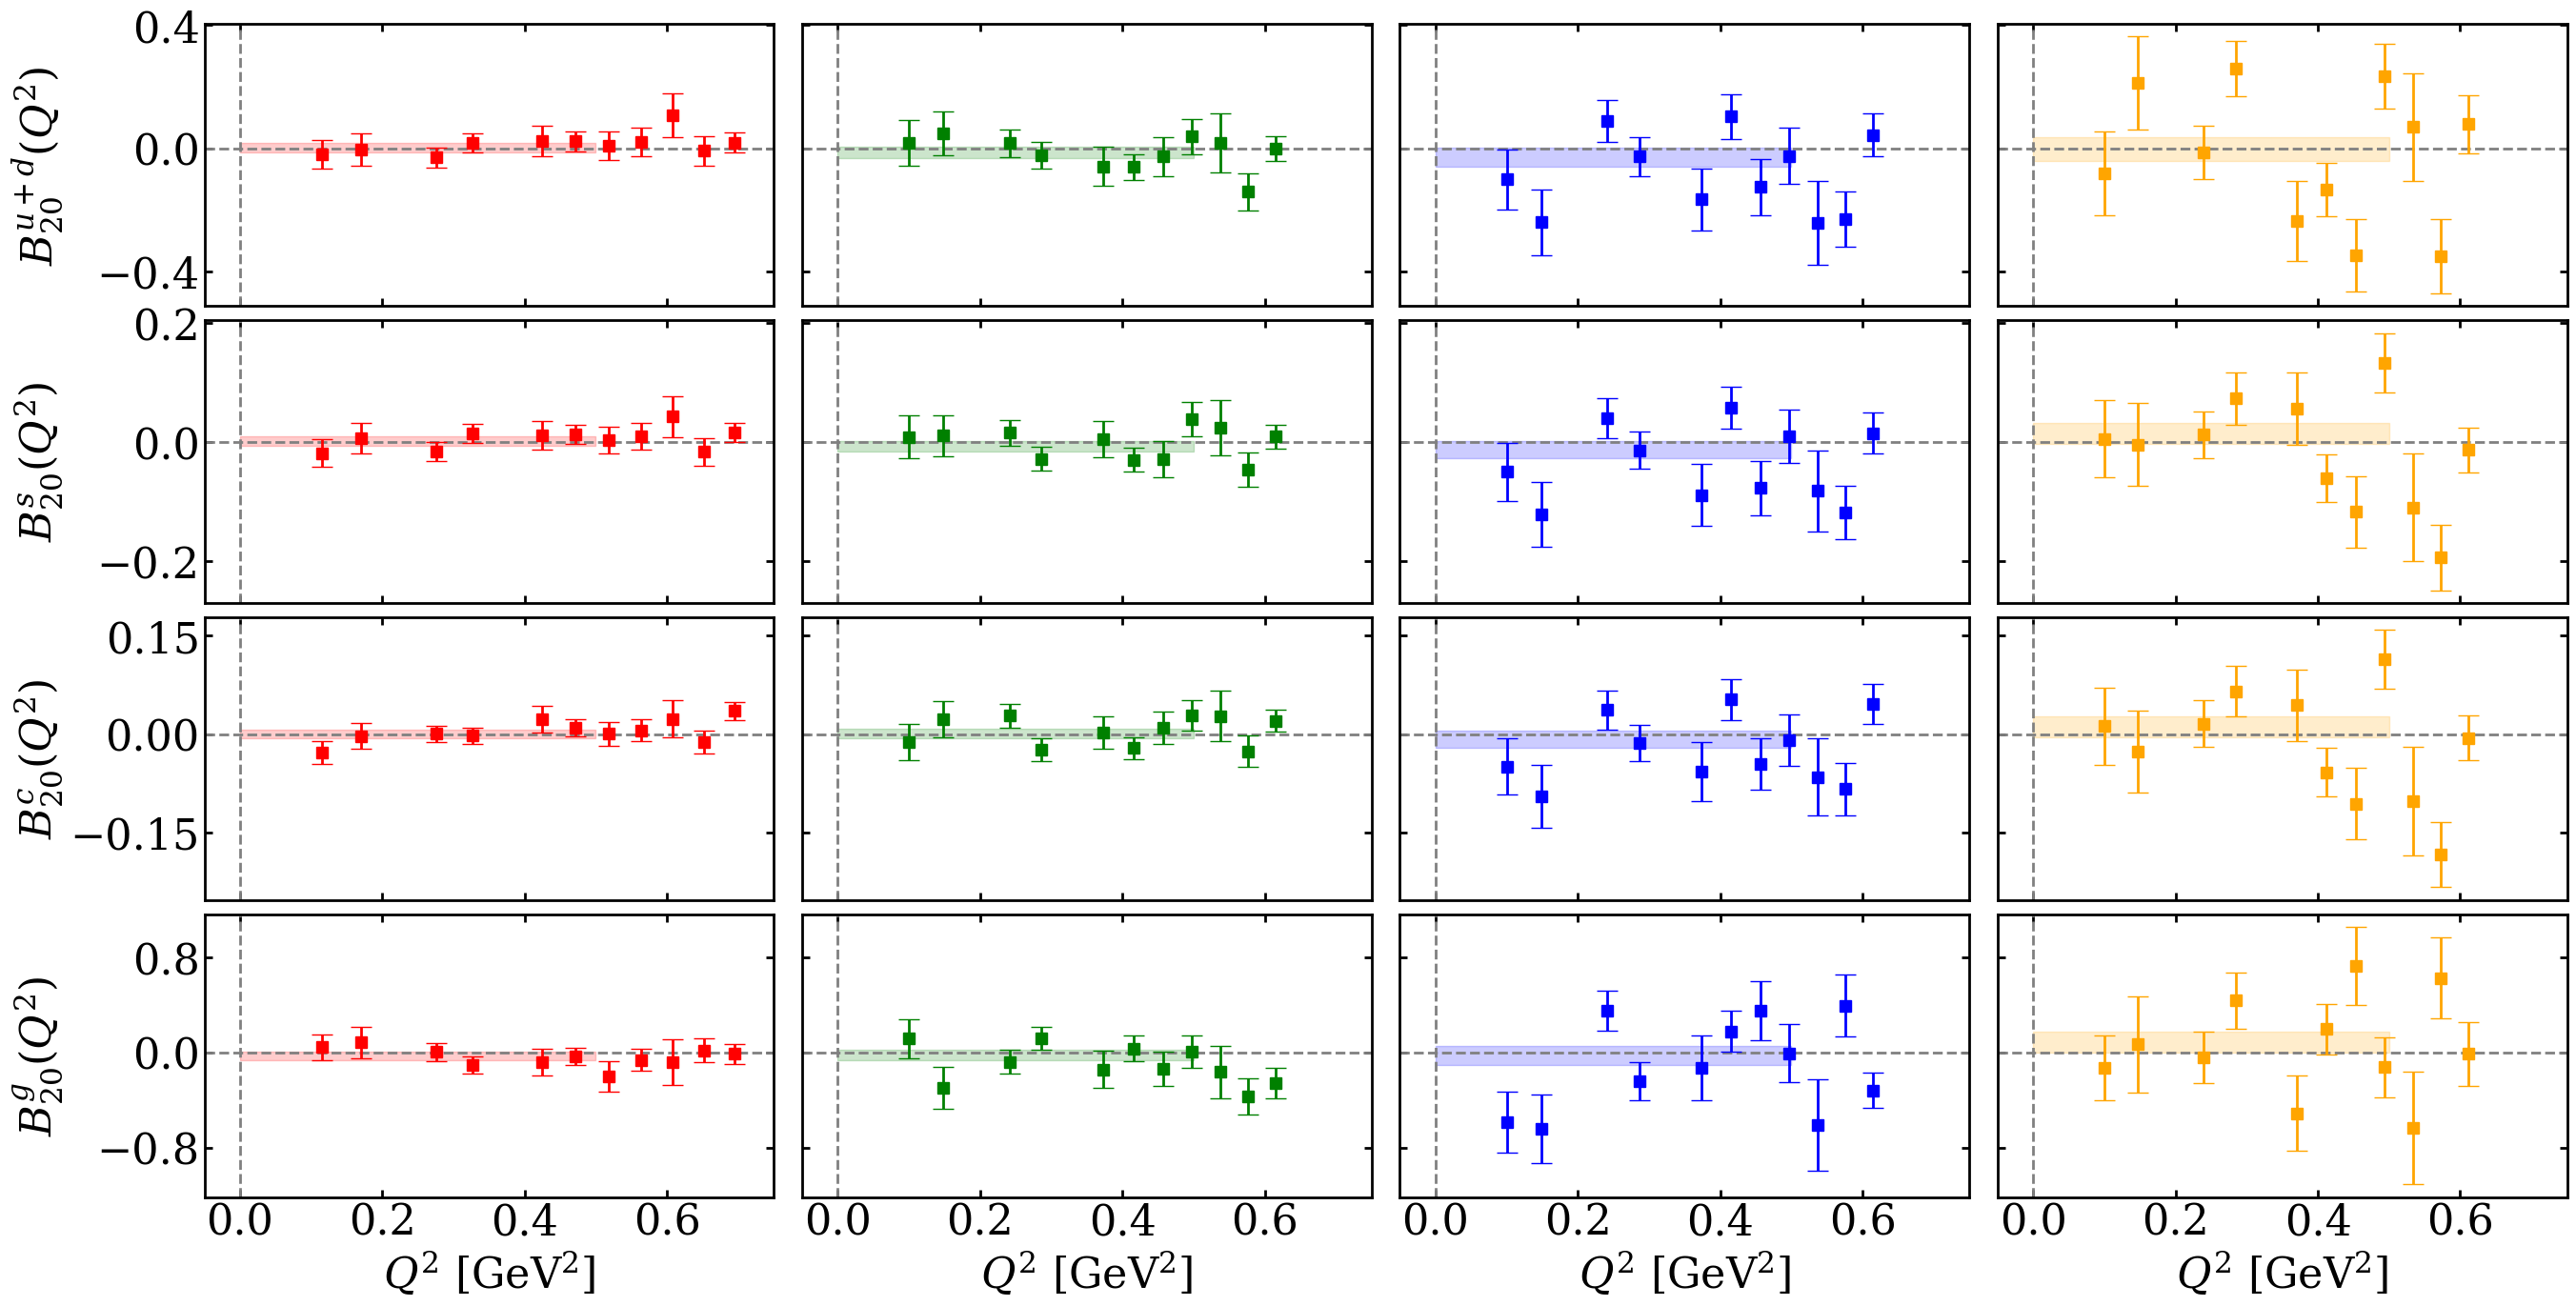

In [ ]:
colors=['r','g','b','orange']
js=['j+;disc','js;disc','jc;disc','jg;stout10']
ylabels=[r'${B}_{20}^{u+d}(Q^2)$',r'${B}_{20}^{s}(Q^2)$',r'${B}_{20}^{c}(Q^2)$',r'${B}_{20}^{g}(Q^2)$']

fig,axs=yu.getFigAxs(len(js),len(enss),Lrow=4,Lcol=8,sharex=True,sharey='row',gridspec_kw={'hspace':0.05, 'wspace':0.05})
xunit=1

for iens,ens in enumerate(enss):
    ax=axs[-1,iens]
    ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
    ax.set_xlim([-0.05,0.75])
    ax.set_xticks(np.arange(0,0.8,0.2))
    # ax.set_xticklabels(['0','0.25','0.5','0.75','1'])
df=[]
for ij,j in enumerate(js):
    c1='all' if j in ['j-;conn'] else 'unequal'
    ax=axs[ij,0]
    ax.set_ylabel(ylabels[ij])
    df_row=[]
    for iens,ens in enumerate(enss):
        yunit=1
        ax=axs[ij,iens]
        yu.addRefLine(ax,0,hv='v')
        color=yu.colors8[iens]
        yu.addRefLine(ax,0)
        
        tftcphy = tftcphy_B20_conn if j in js_conn else tftcphy_B20_discq if j in js_discq else tftcphy_B20_gluon if j in js_gluon else 1/0

        key2bare={cttejn[3:]:cttejn_key2bare_B20[cttejn] for cttejn in cttejn_key2bare_B20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        
        # if 'jg' in j and ens=='e':
        #     n2qpp1=(2,2,0)
        #     key2bare[(ens,j,n2qpp1)]=cttejn_key2bare_B20[(c1,0.6,0.2,ens,j,n2qpp1)]
        
        n2qpp1s=[key[-1] for key in key2bare.keys() if key[0]==ens and key[1]==j]
        Q2s=np.array([yum.n2qpp12Q2(n2qpp1,ens) for n2qpp1 in n2qpp1s])
        ys=np.array([key2bare[(ens,j,n2qpp1)][:] for n2qpp1 in n2qpp1s]).T
        
        mean,err=yu.jackme(ys)
        plt_x=Q2s*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
        
        if j in ['j-;conn']:
            Q2cut=1
            doFit=yu.doFit_dipole
            fitfunc=yu.fitfunc_dipole
        else:
            Q2cut=0.5
            doFit=yu.doFit_const
            fitfunc=yu.fitfunc_const
            
        inds=[i for i,Q2 in enumerate(Q2s) if Q2<=Q2cut]
        Q2s=Q2s[inds]
        ys=ys[:,inds]
    
        pars_jk,chi2_jk,Ndof=doFit(Q2s,ys,corrQ=False) if doFit!=yu.doFit_const else doFit(ys,corrQ=False) 
        
        xs_plt=np.arange(0,Q2cut+1e-5,0.05)
        y_plt=np.array([fitfunc(xs_plt,*pars) for pars in pars_jk])
        mean,err=yu.jackme(y_plt)
        plt_x=xs_plt*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.fill_between(plt_x,plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y[0],plt_yerr[0]))
        # ax.legend()
        df_row.append(yu.un2str(plt_y[0],plt_yerr[0]))
    df.append(df_row)
    ax.yaxis.set_major_locator(yu.MaxNLocator(nbins=3))
    
yu.finalizePlot('B20_Q2_disc',tightQ=False,closeQ=False)

# f=np.array(df)
# df=pd.DataFrame(df,index=[ylabel.replace('Q^2','0') for ylabel in ylabels],columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)

In [20]:
colors=['r','g','b','orange']
js=['j-;conn','j-;conn']
ylabels=[r'${A}_{20}^{u-d}(Q^2)$',r'${B}_{20}^{u-d}(Q^2)$']

fig,axs=yu.getFigAxs(len(js),len(enss),Lrow=4,Lcol=8,sharex=True,sharey='row',gridspec_kw={'hspace':0.05, 'wspace':0.05})
xunit=1

for iens,ens in enumerate(enss):
    color=yu.colors8[iens]
    pars_jk=yu.load_pkl_reg(f'A20_Q2_conn_equal_unequal_j-;conn_{ens}')
    mean,err=yu.jackme(pars_jk[:,0]*ens2RCs_np_me[ens]['Zqq(mu=nu)'])
    ax=axs[0,iens]
    ax.errorbar(-0.03,mean,err,color=color,mfc='white')
    yu.addRefLine(ax,0,hv='v')
    
    pars_jk=yu.load_pkl_reg(f'B20_Q2_conn_unequal_unequal_j-;conn_{ens}')
    mean,err=yu.jackme(pars_jk[:,0]*ens2RCs_np_me[ens]['Zqq(mu!=nu)'])
    ax=axs[1,iens]
    ax.errorbar(-0.03,mean,err,color=color,mfc='white')
    yu.addRefLine(ax,0,hv='v')

for iens,ens in enumerate(enss):
    ax=axs[-1,iens]
    ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
    ax.set_xlim([-0.05,1.05])
    ax.set_xticks(np.arange(0,1.2,0.25))
    ax.set_xticklabels(['0','0.25','0.5','0.75','1'])
df=[]
for ij,j in enumerate(js):
    c1='all'
    ax=axs[ij,0]
    ax.set_ylabel(ylabels[ij])
    df_row=[]
    for iens,ens in enumerate(enss):
        yunit=ens2RCs_np_me[ens]['Zqq(mu=nu)']
        ax=axs[ij,iens]
        color=yu.colors8[iens]
        yu.addRefLine(ax,0)
        
        if ij==0:
            tftcphy = tftcphy_A20_conn if j in js_conn else tftcphy_A20_discq if j in js_discq else tftcphy_A20_gluon if j in js_gluon else 1/0
            key2bare={cttejn[3:]:cttejn_key2bare_A20[cttejn] for cttejn in cttejn_key2bare_A20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        else:
            tftcphy = tftcphy_B20_conn if j in js_conn else tftcphy_B20_discq if j in js_discq else tftcphy_B20_gluon if j in js_gluon else 1/0
            key2bare={cttejn[3:]:cttejn_key2bare_B20[cttejn] for cttejn in cttejn_key2bare_B20.keys() if cttejn[:3]==(c1,tftcphy[0],tftcphy[1])}
        
        n2qpp1s=[key[-1] for key in key2bare.keys() if key[0]==ens and key[1]==j]
        Q2s=np.array([yum.n2qpp12Q2(n2qpp1,ens) for n2qpp1 in n2qpp1s])
        ys=np.array([key2bare[(ens,j,n2qpp1)][:] for n2qpp1 in n2qpp1s]).T
        
        mean,err=yu.jackme(ys)
        plt_x=Q2s*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
        
        if j in ['j-;conn']:
            Q2cut=1
            doFit=yu.doFit_dipole
            fitfunc=yu.fitfunc_dipole
        else:
            Q2cut=0.5
            doFit=yu.doFit_const
            fitfunc=yu.fitfunc_const
            
        inds=[i for i,Q2 in enumerate(Q2s) if Q2<=Q2cut]
        Q2s=Q2s[inds]
        ys=ys[:,inds]
    
        pars_jk,chi2_jk,Ndof=doFit(Q2s,ys,corrQ=False) if doFit!=yu.doFit_const else doFit(ys,corrQ=False) 
        
        xs_plt=np.arange(0,Q2cut+1e-5,0.05)
        y_plt=np.array([fitfunc(xs_plt,*pars) for pars in pars_jk])
        mean,err=yu.jackme(y_plt)
        plt_x=xs_plt*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.fill_between(plt_x,plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y[0],plt_yerr[0]))
        # ax.legend()
        df_row.append(yu.un2str(plt_y[0],plt_yerr[0]))
    df.append(df_row)
    
    ax.set_ylim([[-0.07,0.2],[-0.12,0.35]][ij])
    ax.yaxis.set_major_locator(yu.MaxNLocator(nbins=4))
    
yu.finalizePlot('AB20_Q2_v1_renormalized',tightQ=False,closeQ=True)

# df_B20_conn=np.array(df)
# df=pd.DataFrame(df,index=[ylabel.replace('Q^2','0') for ylabel in ylabels],columns=[yu.ens2label[ens] for ens in enss])
# tex=df.to_latex(
#     escape=False,          # allow latex in labels
#     column_format='ccccc',
#     bold_rows=False,
# )
# tex = tex.replace(r'\toprule'+'\n',r'')
# tex = tex.replace(r'\midrule', r'\hline')
# tex = tex.replace(r'\bottomrule'+'\n',r'')
# print(tex)